# Bayesian Hierarchical Nonlinear Time-Series Modeling

- Train: `batch1.mat` (46 cells)
- Test : `batch2.mat` (known `cycle_life` cells only)
- Input: each cell의 초기 100 사이클(`summary` 기반)
- Target: `cycle_life`

모델 아이디어:
1. 초기 100사이클 `QD` 열화곡선을 계층 비선형 모델로 적합해 셀별 잠재 파라미터(`a,b,c`) 추정
2. 추정된 잠재 파라미터 + 초기 요약 피처로 베이지안 회귀를 수행해 `cycle_life` 예측


In [ ]:
# 실행 환경 준비
# pymc / arviz가 없다면 설치 후 커널 재시작
# !pip install pymc arviz


In [33]:
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mat73
from scipy import stats
from sklearn.metrics import mean_squared_error

import pymc as pm
import arviz as az

warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.CRITICAL)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path('/Users/ryopxd/workspace/data/archive')
BATCH1_PATH = DATA_DIR / 'batch1.mat'
BATCH2_PATH = DATA_DIR / 'batch2.mat'


## 1) 데이터 로드 및 전처리 함수

- `.mat`를 읽어 `batch`를 list-of-dict 형태로 통일
- 각 셀에서 초기 100사이클 summary 시계열(`QD`, `IR`, `Tavg`, `chargetime`) 추출
- 셀 단위 통계 피처(평균/기울기) 생성


In [34]:
def load_batch_cells(path):
    """MAT 파일을 읽고 batch를 list-of-dict로 반환."""
    data = mat73.loadmat(str(path))
    batch = data['batch']

    if isinstance(batch, dict):
        keys = list(batch.keys())
        n = len(batch[keys[0]])
        cells = [{k: batch[k][i] for k in keys} for i in range(n)]
    else:
        cells = batch
    return cells


def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def remove_qd_jump_outliers(qd, jump_thr=0.05, qd_min=0.85, qd_max=1.15):
    """점프 이상치(|ΔQD|>0.05) + 물리 범위(QD) 필터를 동시에 적용."""
    qd = np.asarray(qd, dtype=float)
    if qd.size == 0:
        return np.array([], dtype=bool)

    dq = np.abs(np.diff(qd, prepend=qd[0]))
    mask_jump = dq <= jump_thr
    mask_range = (qd >= qd_min) & (qd <= qd_max)
    mask_finite = np.isfinite(qd)

    return mask_finite & mask_jump & mask_range


def extract_first100_summary(cell):
    """한 셀에서 초기 100 사이클 summary 벡터를 추출(점프/범위 이상치 제거 포함)."""
    s = cell.get('summary', {})
    if not isinstance(s, dict):
        return None

    qd = np.asarray(s.get('QDischarge', []), dtype=float)
    ir = np.asarray(s.get('IR', []), dtype=float)
    tavg = np.asarray(s.get('Tavg', []), dtype=float)
    ct = np.asarray(s.get('chargetime', []), dtype=float)

    n = min(len(qd), len(ir), len(tavg), len(ct), 100)
    if n < 30:
        return None

    qd = qd[:n]
    ir = ir[:n]
    tavg = tavg[:n]
    ct = ct[:n]
    cyc = np.arange(1, n + 1, dtype=float)

    mask_base = np.isfinite(ir) & np.isfinite(tavg) & np.isfinite(ct)
    mask_qd = remove_qd_jump_outliers(qd, jump_thr=0.05, qd_min=0.85, qd_max=1.15)
    mask = mask_base & mask_qd

    qd, ir, tavg, ct, cyc = qd[mask], ir[mask], tavg[mask], ct[mask], cyc[mask]

    if len(qd) < 30:
        return None

    return {
        'cycle': cyc,
        'QD': qd,
        'IR': ir,
        'Tavg': tavg,
        'chargetime': ct,
        'n_total': int(n),
        'n_used': int(len(qd)),
        'n_removed': int(n - len(qd)),
    }


def slope(x, y):
    if len(x) < 2:
        return np.nan
    return np.polyfit(x, y, 1)[0]


def cell_level_features(rec):
    """초기 100사이클로부터 셀 단위 피처 생성."""
    cyc = rec['cycle']
    qd = rec['QD']
    ir = rec['IR']
    tavg = rec['Tavg']
    ct = rec['chargetime']

    out = {
        'qd_mean': np.mean(qd),
        'qd_std': np.std(qd),
        'qd_slope': slope(cyc, qd),
        'ir_mean': np.mean(ir),
        'ir_std': np.std(ir),
        'ir_slope': slope(cyc, ir),
        'tavg_mean': np.mean(tavg),
        'tavg_slope': slope(cyc, tavg),
        'ct_mean': np.mean(ct),
        'ct_slope': slope(cyc, ct),
        'qd_drop_10_100': (qd[min(99, len(qd)-1)] - qd[min(9, len(qd)-1)]),
        'n_used_points': rec.get('n_used', np.nan),
        'n_removed_points': rec.get('n_removed', np.nan),
    }
    return out


## 2) batch1 / batch2 데이터셋 구성

- `batch1` : 학습용 (cycle_life 유효 셀)
- `batch2` : 테스트용 (cycle_life 유효 셀만 평가)
- 열화모델 학습은 초기 100사이클 `QD` 시계열을 사용


In [35]:
b1_cells = load_batch_cells(BATCH1_PATH)
b2_cells = load_batch_cells(BATCH2_PATH)

all_cell_rows = []
all_qd_rows = []

def append_batch(cells, split_name):
    for local_id, cell in enumerate(cells):
        cyc_life = safe_float(cell.get('cycle_life', np.nan))
        rec = extract_first100_summary(cell)
        if rec is None:
            continue

        # cell-level features
        feats = cell_level_features(rec)

        global_id = f'{split_name}_{local_id}'
        row = {
            'global_id': global_id,
            'split': split_name,
            'cell_id': local_id,
            'cycle_life': cyc_life,
        }
        row.update(feats)
        all_cell_rows.append(row)

        # long-format QD time-series for nonlinear degradation model
        for t, qd in zip(rec['cycle'], rec['QD']):
            all_qd_rows.append({
                'global_id': global_id,
                'split': split_name,
                't': float(t),
                't_norm': float(t / 100.0),
                'QD': float(qd),
            })

append_batch(b1_cells, 'train')
append_batch(b2_cells, 'test')

cell_df = pd.DataFrame(all_cell_rows)
qd_long = pd.DataFrame(all_qd_rows)

print('cell_df shape:', cell_df.shape)
print(cell_df.groupby('split')['global_id'].count())
print('known cycle_life by split:')
print(cell_df.groupby('split')['cycle_life'].apply(lambda s: s.notna().sum()))

# 평가 가능한 test 셀 수
print('test evaluable cells:', cell_df.query("split=='test' and cycle_life==cycle_life").shape[0])


cell_df shape: (93, 17)
split
test     47
train    46
Name: global_id, dtype: int64
known cycle_life by split:
split
test     39
train    46
Name: cycle_life, dtype: int64
test evaluable cells: 39


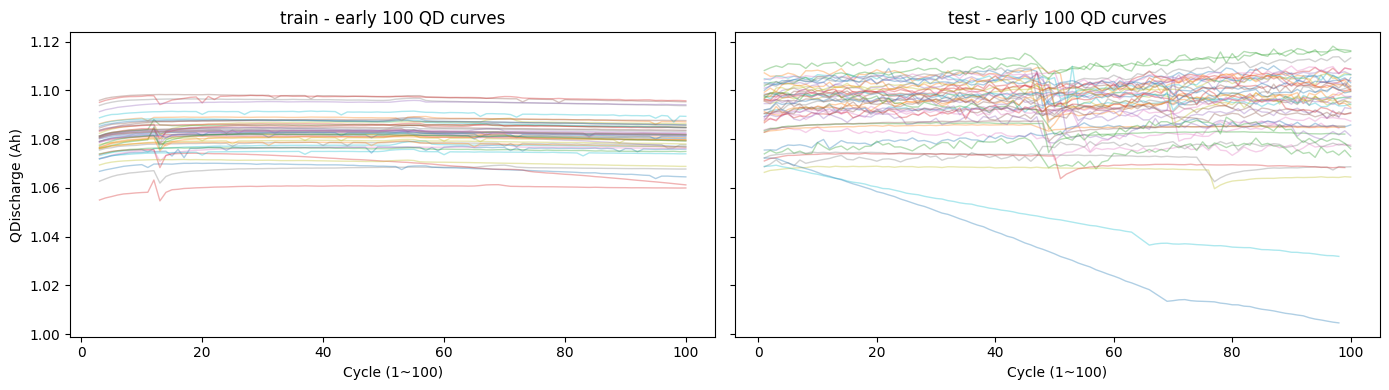

In [ ]:
# 간단 시각화: 초기 100사이클 QD 패턴 (train/test)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, sp in zip(axes, ['train', 'test']):
    sub = qd_long[qd_long['split'] == sp]
    for gid, g in sub.groupby('global_id'):
        ax.plot(g['t'], g['QD'], alpha=0.35, lw=1)
    ax.set_title(f'{sp} - early 100 QD curves')
    ax.set_xlabel('Cycle (1~100)')
axes[0].set_ylabel('QDischarge (Ah)')
plt.tight_layout()
plt.show()

log(varience(del(100)-del(10)))


In [37]:
# 1) qd_long 현재 상태 점검
print(qd_long['QD'].describe())
print('max QD:', qd_long['QD'].max(), 'min QD:', qd_long['QD'].min())
print('out-of-range count:', ((qd_long['QD'] < 0.85) | (qd_long['QD'] > 1.15)).sum())


count    9166.000000
mean        1.086883
std         0.013107
min         1.004601
25%         1.080290
50%         1.085808
75%         1.096415
max         1.118173
Name: QD, dtype: float64
max QD: 1.1181728 min QD: 1.0046005
out-of-range count: 0


## 3) 베이지안 계층 비선형 열화모델 (MCMC)

모형:
- `QD_it ~ Normal(mu_it, sigma_qd)`
- `mu_it = a_i - b_i * (exp(c_i * t_norm) - 1)`
- `a_i, b_i, c_i`는 셀별 파라미터이며 계층 사전분포를 가짐

이 단계에서 각 셀의 잠재 열화 파라미터(`a,b,c`)를 posterior로 추정한다.


In [38]:
# 인덱스 매핑
all_ids = cell_df['global_id'].tolist()
id_to_idx = {gid: i for i, gid in enumerate(all_ids)}

qd_long = qd_long.copy()
qd_long['cell_idx'] = qd_long['global_id'].map(id_to_idx)

cell_idx_obs = qd_long['cell_idx'].to_numpy(dtype=int)
t_norm_obs = qd_long['t_norm'].to_numpy(dtype=float)
qd_obs = qd_long['QD'].to_numpy(dtype=float)

n_cells_all = len(all_ids)

with pm.Model() as degradation_model:
    # Hyper-priors
    mu_a = pm.Normal('mu_a', mu=1.08, sigma=0.05)
    sigma_a = pm.HalfNormal('sigma_a', sigma=0.05)

    mu_log_b = pm.Normal('mu_log_b', mu=np.log(0.02), sigma=1.0)
    sigma_log_b = pm.HalfNormal('sigma_log_b', sigma=1.0)

    mu_log_c = pm.Normal('mu_log_c', mu=np.log(0.6), sigma=1.0)
    sigma_log_c = pm.HalfNormal('sigma_log_c', sigma=1.0)

    # Cell-specific parameters
    a = pm.Normal('a', mu=mu_a, sigma=sigma_a, shape=n_cells_all)
    b = pm.LogNormal('b', mu=mu_log_b, sigma=sigma_log_b, shape=n_cells_all)
    c = pm.LogNormal('c', mu=mu_log_c, sigma=sigma_log_c, shape=n_cells_all)

    mu_qd = a[cell_idx_obs] - b[cell_idx_obs] * (pm.math.exp(c[cell_idx_obs] * t_norm_obs) - 1.0)

    sigma_qd = pm.HalfNormal('sigma_qd', sigma=0.02)
    pm.Normal('qd_like', mu=mu_qd, sigma=sigma_qd, observed=qd_obs)

    idata_deg = pm.sample(
        draws=3000,
        tune=3000,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        chains=4,
        cores=2,
    )


Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 2 jobs)
NUTS: [mu_a, sigma_a, mu_log_b, sigma_log_b, mu_log_c, sigma_log_c, a, b, c, sigma_qd]
INFO:pymc.sampling.mcmc:NUTS: [mu_a, sigma_a, mu_log_b, sigma_log_b, mu_log_c, sigma_log_c, a, b, c, sigma_qd]


Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 2869 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 2869 seconds.


In [39]:
# MCMC 진단
az.summary(idata_deg, var_names=['mu_a','sigma_a','mu_log_b','sigma_log_b','mu_log_c','sigma_log_c','sigma_qd'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,1.088,0.001,1.086,1.090,0.000,0.000,30936.0,7443.0,1.0
sigma_a,0.011,0.001,0.010,0.013,0.000,0.000,24434.0,8276.0,1.0
mu_log_b,-6.366,0.573,-7.437,-5.296,0.015,0.007,1415.0,2926.0,1.0
sigma_log_b,3.029,0.356,2.363,3.690,0.006,0.003,3447.0,6213.0,1.0
mu_log_c,-2.797,0.525,-3.812,-1.856,0.015,0.007,1155.0,2761.0,1.0
sigma_log_c,2.085,0.320,1.502,2.690,0.008,0.004,1479.0,3659.0,1.0
sigma_qd,0.002,0.000,0.002,0.002,0.000,0.000,24202.0,8383.0,1.0


In [40]:
# 셀별 잠재 파라미터 posterior mean 추출
post = idata_deg.posterior
a_hat = post['a'].mean(dim=('chain', 'draw')).values
b_hat = post['b'].mean(dim=('chain', 'draw')).values
c_hat = post['c'].mean(dim=('chain', 'draw')).values

latent_df = pd.DataFrame({
    'global_id': all_ids,
    'a_hat': a_hat,
    'b_hat': b_hat,
    'c_hat': c_hat,
})

# 중복 merge로 suffix(_x/_y) 생기지 않도록 기존 latent 컬럼 제거 후 merge
cell_df = cell_df.drop(columns=['a_hat', 'b_hat', 'c_hat'], errors='ignore')
cell_df = cell_df.merge(latent_df, on='global_id', how='left')

# 혹시 남은 suffix 컬럼이 있으면 정리
for base in ['a_hat', 'b_hat', 'c_hat']:
    if base not in cell_df.columns:
        cand = [c for c in cell_df.columns if c.startswith(base + '_')]
        if len(cand) > 0:
            pick = f'{base}_y' if f'{base}_y' in cand else (f'{base}_x' if f'{base}_x' in cand else cand[0])
            cell_df[base] = cell_df[pick]

drop_cols = [c for c in cell_df.columns if c.endswith('_x') or c.endswith('_y')]
cell_df = cell_df.drop(columns=drop_cols, errors='ignore')

print('latent cols ready:', [c for c in ['a_hat','b_hat','c_hat'] if c in cell_df.columns])
cell_df.head()


latent cols ready: ['a_hat', 'b_hat', 'c_hat']


,global_id,split,cell_id,cycle_life,qd_mean,qd_std,qd_slope,ir_mean,ir_std,ir_slope,tavg_mean,tavg_slope,ct_mean,ct_slope,qd_drop_10_100,n_used_points,n_removed_points,a_hat,b_hat,c_hat
0,train_0,train,0,1190.0,1.075995,0.001064,0.000013,0.016618,0.000047,6.381323e-07,31.615335,-0.001839,13.385567,-0.000160,0.000856,96,4,1.076024,0.005567,0.123598
1,train_1,train,1,1179.0,1.081308,0.001027,0.000002,0.016748,0.001701,9.468873e-06,31.326860,-0.002978,13.374172,-0.000442,-0.003960,98,2,1.081362,0.006735,0.144182
2,train_2,train,2,1177.0,1.085427,0.000863,0.000007,0.016597,0.001686,9.684520e-06,31.476055,-0.002971,13.379269,-0.000076,-0.003113,98,2,1.085465,0.005179,0.130512
3,train_3,train,3,1226.0,1.085002,0.000959,0.000014,0.016144,0.001640,9.099222e-06,29.939103,-0.002132,12.053733,-0.000157,0.000604,98,2,1.085030,0.003941,0.112183
4,train_4,train,4,1227.0,1.082889,0.000999,0.000017,0.016498,0.001676,8.750377e-06,31.446739,-0.000370,12.053773,0.000084,0.000952,98,2,1.082914,0.004638,0.116631


## 4) 베이지안 회귀 (cycle_life 예측)

- 학습: batch1(`train`)의 `cycle_life`
- 테스트: batch2(`test`) 중 `cycle_life`가 존재하는 셀
- 목표변수는 안정화를 위해 `log(cycle_life)`로 회귀 후 역변환


In [41]:
# 학습/테스트 분리
train_df = cell_df[(cell_df['split'] == 'train') & (cell_df['cycle_life'].notna())].copy()
test_df  = cell_df[(cell_df['split'] == 'test') & (cell_df['cycle_life'].notna())].copy()

# small-sample 안정화를 위해 기본 피처를 축소하고, latent 파라미터가 있으면 추가
base_cols = ['qd_slope', 'ir_slope', 'tavg_mean', 'ct_mean', 'qd_drop_10_100']
latent_cols = ['a_hat', 'b_hat', 'c_hat']
use_latent = all(c in cell_df.columns for c in latent_cols)
feature_cols = (latent_cols + base_cols) if use_latent else base_cols

print('use_latent_features:', use_latent)
print('feature_cols:', feature_cols)

X_train = train_df[feature_cols].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_train = train_df['cycle_life'].to_numpy(dtype=float)
y_test = test_df['cycle_life'].to_numpy(dtype=float)

# 표준화 (train 기준)
mu_x = X_train.mean(axis=0)
std_x = X_train.std(axis=0)
std_x[std_x == 0] = 1.0

X_train_z = (X_train - mu_x) / std_x
X_test_z = (X_test - mu_x) / std_x

y_train_log = np.log(y_train)

print('train shape:', X_train_z.shape, 'test shape:', X_test_z.shape)
print('X_train_z range:', float(np.nanmin(X_train_z)), float(np.nanmax(X_train_z)))


use_latent_features: True
feature_cols: ['a_hat', 'b_hat', 'c_hat', 'qd_slope', 'ir_slope', 'tavg_mean', 'ct_mean', 'qd_drop_10_100']
train shape: (46, 8) test shape: (39, 8)
X_train_z range: -6.377687803190833 4.4764322332263395


In [42]:
# a_hat/b_hat/c_hat가 없으면 summary-only 모델로 자동 fallback
base_cols = [
    'qd_mean', 'qd_std', 'qd_slope',
    'ir_mean', 'ir_std', 'ir_slope',
    'tavg_mean', 'tavg_slope',
    'ct_mean', 'ct_slope',
    'qd_drop_10_100',
]

latent_cols = ['a_hat', 'b_hat', 'c_hat']
use_latent = all(c in cell_df.columns for c in latent_cols)

feature_cols = (latent_cols + base_cols) if use_latent else base_cols
print("use_latent_features:", use_latent)
print("feature_cols:", feature_cols)

train_df = cell_df[(cell_df['split'] == 'train') & (cell_df['cycle_life'].notna())].copy()
test_df  = cell_df[(cell_df['split'] == 'test') & (cell_df['cycle_life'].notna())].copy()

X_train = train_df[feature_cols].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_train = train_df['cycle_life'].to_numpy(dtype=float)
y_test = test_df['cycle_life'].to_numpy(dtype=float)

mu_x = X_train.mean(axis=0)
std_x = X_train.std(axis=0)
std_x[std_x == 0] = 1.0

X_train_z = (X_train - mu_x) / std_x
X_test_z = (X_test - mu_x) / std_x
y_train_log = np.log(y_train)

print('train shape:', X_train_z.shape, 'test shape:', X_test_z.shape)


use_latent_features: True
feature_cols: ['a_hat', 'b_hat', 'c_hat', 'qd_mean', 'qd_std', 'qd_slope', 'ir_mean', 'ir_std', 'ir_slope', 'tavg_mean', 'tavg_slope', 'ct_mean', 'ct_slope', 'qd_drop_10_100']
train shape: (46, 14) test shape: (39, 14)


In [43]:
with pm.Model() as reg_model:
    p = X_train_z.shape[1]

    alpha = pm.Normal('alpha', mu=6.5, sigma=2.0)
    beta = pm.Normal('beta', mu=0.0, sigma=1.0, shape=p)
    sigma = pm.HalfNormal('sigma', sigma=1.0)

    mu = alpha + pm.math.dot(X_train_z, beta)
    pm.Normal('y_like', mu=mu, sigma=sigma, observed=y_train_log)

    idata_reg = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.92,
        random_seed=RANDOM_SEED,
        chains=2,
        cores=2,
    )


Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]
INFO:pymc.sampling.mcmc:NUTS: [alpha, beta, sigma]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.
INFO:pymc.sampling.mcmc:Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics


In [44]:
# posterior predictive median / interval on test (stable version)
post = idata_reg.posterior
alpha_s = post['alpha'].stack(sample=('chain','draw')).values  # (S,)
beta_s = post['beta'].stack(sample=('chain','draw')).values    # (p,S)

# mu samples: (S, n_test)
mu_test_s = alpha_s[:, None] + (beta_s.T @ X_test_z.T)

# 디버그 안정화: 관측노이즈를 추가하지 않고 중앙 경향으로 예측
ylog_pred_s = np.clip(mu_test_s, np.log(250.0), np.log(1800.0))
y_test_pred_samples = np.exp(ylog_pred_s)

y_test_pred = np.median(y_test_pred_samples, axis=0)
y_test_lo = np.percentile(y_test_pred_samples, 5, axis=0)
y_test_hi = np.percentile(y_test_pred_samples, 95, axis=0)

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.3f}%')

pred_df = test_df[['global_id','cell_id','cycle_life']].copy()
pred_df['y_pred'] = y_test_pred
pred_df['y_pred_lo_5'] = y_test_lo
pred_df['y_pred_hi_95'] = y_test_hi
pred_df = pred_df.rename(columns={'cycle_life':'y_true'}).sort_values('y_true')
pred_df.head(10)


RMSE: 1034.184
MAPE: 198.127%


,global_id,cell_id,y_true,y_pred,y_pred_lo_5,y_pred_hi_95
65,test_19,19,392.0,1108.872483,762.351853,1661.769761
52,test_6,6,393.0,1294.385249,818.961463,1800.000000
61,test_15,15,396.0,1553.832364,960.091537,1800.000000
67,test_21,21,408.0,934.915013,652.068877,1345.350477
76,test_30,30,412.0,1800.000000,1800.000000,1800.000000
51,test_5,5,416.0,1800.000000,250.000000,1800.000000
48,test_2,2,424.0,778.788850,534.141313,1167.105225
77,test_31,31,425.0,1559.058361,1151.411439,1800.000000
60,test_14,14,426.0,1800.000000,1800.000000,1800.000000
74,test_28,28,437.0,1800.000000,1800.000000,1800.000000


In [45]:
# 결과 시각화
plt.figure(figsize=(6, 6))
plt.scatter(pred_df['y_true'], pred_df['y_pred'], alpha=0.75)
lo = min(pred_df['y_true'].min(), pred_df['y_pred'].min())
hi = max(pred_df['y_true'].max(), pred_df['y_pred'].max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
plt.xlabel('True cycle_life (batch2)')
plt.ylabel('Predicted cycle_life')
plt.title(f'Bayesian prediction on batch2
RMSE={rmse:.2f}, MAPE={mape:.2f}%')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 불확실성 구간 예시 출력
pred_df[['global_id','y_true','y_pred','y_pred_lo_5','y_pred_hi_95']].head(15)

SyntaxError: unterminated string literal (detected at line 9) (2995569606.py, line 9)

## 5) 해석 가이드

- `a_hat`: 초기 용량 레벨
- `b_hat, c_hat`: 초기 100사이클에서의 열화 강도/곡률
- 회귀계수(`beta`) posterior를 보면 어떤 신호가 수명에 더 기여하는지 해석 가능
- 샘플이 작으므로 posterior interval(불확실성)까지 함께 보고 판단
